In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
import ast
import matplotlib.pyplot as plt
import forestplot as fp
from scipy import stats

In [2]:
ancestry = pd.read_csv('/home/jupyter/workspace/vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/ancestry/echo_v4_r2.ancestry_preds.tsv', sep='\t')
ancestry['pca_features'] = ancestry['pca_features'].apply(ast.literal_eval)
pca_df = pd.DataFrame(ancestry['pca_features'].tolist(), index=ancestry.index)
pca_df.columns = [f'PC{i+1}' for i in range(16)]
ancestry = pd.concat([ancestry.drop(columns=['pca_features']), pca_df], axis=1)
ancestry = ancestry[ancestry['ancestry_pred'] == ancestry['ancestry_pred_other']]
deprivation = pd.read_csv('../deprivation_index.tsv', sep='\t')

In [3]:
populations = ancestry.ancestry_pred.unique().tolist()
relatedness = pd.read_csv('~/workspace/vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness_flagged_samples.tsv', sep='\t')
traits = ['Lymphocyte_count','FEV1_FVC', 'LDL_C']

In [4]:
def simplify_fev1_fvc_label(label):
    """
    Maps complex FEV1/FVC concepts to concise, descriptive labels.
    """
    mapping = {
        # Add any specific FEV1/FVC variants if needed, otherwise acts as a direct mapping/fallback
    }
    return mapping.get(label, label)

In [5]:
def simplify_ldlc_label(label):
    """
    Maps complex clinical LDL cholesterol concepts to concise, descriptive labels.
    """
    mapping = {
        'Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation': 'LDL-C (Calculation)',
        'Cholesterol in LDL [Mass/volume] in Serum or Plasma by Direct assay': 'LDL-C (Direct assay)',
        'Cholesterol in LDL [Mass/volume] in Serum or Plasma': 'LDL-C (General)'
    }
    
    return mapping.get(label, "Unknown")

# Example usage with your dataframe:
# df['simplified_label'] = df['standard_concept_name'].apply(simplify_ldlc_label)

In [6]:
def simplify_egfr_label(label):
    """
    Maps complex clinical eGFR concepts to concise, descriptive labels.
    """
    mapping = {
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD)',
        'Glomerular filtration rate/1.73 sq M.predicted among blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD, Black)',
        'Glomerular filtration rate/1.73 sq M.predicted among non-blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD, Non-Black)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI)',
        'Glomerular filtration rate/1.73 sq M.predicted among blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI, Black)',
        'Glomerular filtration rate/1.73 sq M.predicted among non-blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI, Non-Black)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI 2021)': 'eGFR (CKD-EPI 2021)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood': 'eGFR (General)',
        'Creatinine and Glomerular filtration rate.predicted panel - Serum, Plasma or Blood': 'eGFR (Panel)'
    }
    
    return mapping.get(label, "Unknown")

# Example usage with your dataframe:
# df['simplified_label'] = df['standard_concept_name'].apply(simplify_egfr_label)

In [7]:
def simplify_lymphocyte_label(label):
    """
    Maps complex clinical lymphocyte count concepts to concise, descriptive labels.
    """
    mapping = {
        'Lymphocytes [#/volume] in Blood by Automated count': 'Lymphocyte count (Automated)',
        'Lymphocytes [#/volume] in Blood by Manual count': 'Lymphocyte count (Manual)',
        'Lymphocytes [#/volume] in Blood': 'Lymphocyte count (General)'
    }
    
    return mapping.get(label, "Unknown")

# Example usage with your dataframe:
# df['simplified_label'] = df['standard_concept_name'].apply(simplify_lymphocyte_label)

In [8]:
trait_simplifiers = {
    'Lymphocyte_count': simplify_lymphocyte_label,
    'eGFR': simplify_egfr_label,
    'FEV1_FVC': simplify_fev1_fvc_label,
    'LDL_C': simplify_ldlc_label
}

In [9]:
covariates = ['age_at_measurement', 'sex', 'deprivation_index', 'age_age', 'age_sex'] + [f'PC{i+1}' for i in range(16)]
overlap_dfs = []
pred_dfs = []
for t in traits:
    # 1. File loading (Consider changing to pd.read_parquet() for massive speedups!)
    pgs = pd.read_csv(f'../score/{t}/genome_wide_pgs.tsv', sep='\t')
    pheno = pd.read_csv(f'../Phenotype/{t}_new.tsv', sep='\t')
    pheno = pheno[~pheno['id'].isin(relatedness['sample_id'])]
    pheno['short_name'] = pheno["standard_concept_name"].apply(trait_simplifiers[t])
    if t == 'Lymphocyte_count':
        pheno = pheno[~pheno['standard_concept_name'].str.lower().str.contains('leukocytes', na=False)]
    #if t == 'eGFR':
        #pheno = pheno[~pheno['short_name'].str.contains('MDRD')]
    # 2. Merge efficiently using inner joins to automatically drop unmatched IDs
    df = pgs.merge(pheno, left_on='#IID', right_on='id', how='inner')
    df = df.merge(ancestry, left_on='#IID', right_on='research_id', how='inner')
    df = df.merge(deprivation[['person_id', 'deprivation_index']], left_on='#IID', right_on='person_id', how='inner')

        # 3. Vectorize feature engineering
    df['age_age'] = df['age_at_measurement'] ** 2 # slightly cleaner than multiplication
    df['sex'] = df['sex_at_birth'].map({'Female': 0, 'Male': 1}).astype(float)
    df['age_sex'] = df['age_at_measurement'] * df['sex']

    cols_to_keep = ['#IID', 'ancestry_pred', 'ancestry_pred_other', 'phenotype', 'BETA_SUM', 'short_name'] + covariates
    df_clean = df[cols_to_keep].dropna()
    
    df_clean = df_clean[df_clean['ancestry_pred'] == 'afr']

    if t == 'eGFR':
        df_clean = df_clean[~df_clean['short_name'].str.contains('Non-Black', na=False)]
    pivot_df = pd.crosstab(df_clean['#IID'], df_clean['short_name'])
    overlap_matrix = pivot_df.T.dot(pivot_df)
    overlap_dfs.append(overlap_matrix)
    pred_dfs.append(df_clean)
    #overlap_matrix.to_csv(f'{t}_overlap_matrix.tsv', sep='\t')

In [11]:
def greedy_phenotype_selection(df_patients, concept_columns):
    """
    df_patients: DataFrame where rows are individuals and columns are concept IDs 
                 containing boolean or binary values (True/False or 1/0) indicating presence.
    concept_columns: List of valid concept ID columns to consider.
    """
    uncovered_individuals = set(df_patients.index)
    selected_concepts = []
    
    while uncovered_individuals:
        best_concept = None
        best_new_individuals = set()
        
        # Find the concept that covers the maximum number of currently uncovered individuals
        for concept in concept_columns:
            if concept in selected_concepts:
                continue
                
            # Individuals who have this measurement and are still uncovered
            has_concept = set(df_patients.index[df_patients[concept] == 1])
            new_covered = has_concept.intersection(uncovered_individuals)
            
            if len(new_covered) > len(best_new_individuals):
                best_new_individuals = new_covered
                best_concept = concept
                
        # If no concept adds any new individuals, break out of the loop
        if not best_concept or not best_new_individuals:
            break
            
        selected_concepts.append(best_concept)
        # Remove newly covered individuals from the pool
        uncovered_individuals -= best_new_individuals
        
    return selected_concepts

In [12]:
non_overlapping_dfs = []
for i in np.arange(len(traits)):
    df_patients = pred_dfs[i][['#IID', 'short_name']].pivot_table(
    index='#IID', 
    columns='short_name', 
    aggfunc=lambda x: 1, # or len/count if you just want to check if an entry exists
    fill_value=0
    )
    
    concept_order = greedy_phenotype_selection(df_patients, pred_dfs[i].short_name.unique().tolist())
    concept_priority = {concept: i for i, concept in enumerate(concept_order)}

    pheno_df = pred_dfs[i].copy()
    
    pheno_df['priority'] = pheno_df['short_name'].map(concept_priority)
    pheno_df = pheno_df.sort_values(by=['#IID', 'priority'])
    
    non_overlapping_pheno = pheno_df.drop_duplicates(subset=['#IID'], keep='first')
    non_overlapping_pheno = non_overlapping_pheno.drop(columns=['priority'])

    non_overlapping_dfs.append(non_overlapping_pheno)  

In [13]:
def ci_rsq(rsq, n, k, level=0.95):
    """
    Replicates the exact math from psychometric::CI.Rsq in R.
    Computes the confidence interval for R-squared using the Olkin & Finn approximation.
    """
    # Calculate Standard Error of R-squared
    sersq = np.sqrt((4 * rsq * (1 - rsq)**2 * (n - k - 1)**2) / ((n**2 - 1) * (n + 3)))
    
    # Calculate Z-score for the given confidence level (e.g., 1.96 for 95%)
    z = norm.ppf((1 + level) / 2)
    
    lcl = rsq - z * sersq
    ucl = rsq + z * sersq
    
    return lcl, ucl

def eval_R2_CI(data, response, pgs_term=None, covariates=None, level=0.95):
    if covariates is None:
        covariates = []
        
    all_predictors = covariates.copy()
    if pgs_term is not None:
        all_predictors = [pgs_term] + all_predictors
        
    if len(all_predictors) == 0:
        raise ValueError("You must provide at least a pgs_term or covariates.")
        
    X = data[all_predictors]
    X = sm.add_constant(X)
    y = data[response]
    
    model = sm.OLS(y, X)
    results = model.fit()
    
    # --- NEW: Extract Beta and SE along with the p-value ---
    if pgs_term is not None:
        p_val = results.pvalues[pgs_term]
        beta = results.params[pgs_term]
        se = results.bse[pgs_term]
    else:
        p_val = results.pvalues[covariates].min()
        beta = np.nan # Covariate-only models don't have a PGS beta
        se = np.nan
        
    rsq = results.rsquared
    n = len(data)
    k = len(all_predictors)
    lcl, ucl = ci_rsq(rsq, n, k, level) 
    
    res_df = pd.DataFrame([{
        'response': response,
        'pgs_term': pgs_term if pgs_term else "None",
        'covariates': "+".join(covariates) if covariates else "None",
        'metric': 'R2',
        'eval': rsq,
        'l_eval': lcl,
        'u_eval': ucl,
        'P_pgs': p_val,
        'beta': beta,  # Added to output
        'se': se,      # Added to output
        'n': n
    }])
    
    return res_df

# (No changes needed to eval_CI wrapper!)
def eval_CI(data, response, pgs_term=None, covariates=None, family="gaussian", level=0.95):
    """
    Main wrapper function to evaluate predictive performance, 
    isolating the p-value of the primary PGS term.
    """
    if covariates is None:
        covariates = []
        
    if family not in ["gaussian", "binomial"]:
        raise ValueError("Family must be 'gaussian' or 'binomial'")
        
    if family == "gaussian":
        # Pass the separated terms down to the R2 function
        return eval_R2_CI(data, response, pgs_term, covariates, level)
    else:
        # When you build your AUROC function, it will now safely 
        # receive the separated pgs_term and covariates as well!
        # return eval_AUROC_CI(data, response, pgs_term, covariates, level)
        pass

In [14]:
r2_dfs = []
for i in np.arange(len(traits)):
    df = non_overlapping_dfs[i].copy()
    if i == 1:
        df = df[df['phenotype'] < 1000]
    for m in df['short_name'].unique().tolist():
        subset = df[df['short_name'] == m]
        if len(subset) <= 3:
            print(m)
        if len(subset) > 3:
            pgs_only = eval_CI(subset, 'phenotype', 'BETA_SUM')
            pgs_only['trait'] = traits[i]
            pgs_only['short_name'] = m
            r2_dfs.append(pgs_only)

In [15]:
forest_input = pd.concat(r2_dfs)

In [16]:
forest_input['cohort'] = 'All of Us (PRISM)'

In [19]:
pred_dfs = []
for t in traits:
    # 1. File loading (Consider changing to pd.read_parquet() for massive speedups!)
    pgs = pd.read_csv(f'../score/{t}_baseline/genome_wide_pgs_filtered.tsv', sep='\t')
    pheno = pd.read_csv(f'../Phenotype/{t}_new.tsv', sep='\t')
    pheno = pheno[~pheno['id'].isin(relatedness['sample_id'])]
    pheno['short_name'] = pheno["standard_concept_name"].apply(trait_simplifiers[t])
    if t == 'Lymphocyte_count':
        pheno = pheno[~pheno['standard_concept_name'].str.lower().str.contains('leukocytes', na=False)]
    #if t == 'eGFR':
        #pheno = pheno[~pheno['short_name'].str.contains('MDRD')]
    # 2. Merge efficiently using inner joins to automatically drop unmatched IDs
    df = pgs.merge(pheno, left_on='#IID', right_on='id', how='inner')
    df = df.merge(ancestry, left_on='#IID', right_on='research_id', how='inner')
    df = df.merge(deprivation[['person_id', 'deprivation_index']], left_on='#IID', right_on='person_id', how='inner')

        # 3. Vectorize feature engineering
    df['age_age'] = df['age_at_measurement'] ** 2 # slightly cleaner than multiplication
    df['sex'] = df['sex_at_birth'].map({'Female': 0, 'Male': 1}).astype(float)
    df['age_sex'] = df['age_at_measurement'] * df['sex']

    cols_to_keep = ['#IID', 'ancestry_pred', 'ancestry_pred_other', 'phenotype', 'BETA_SUM', 'short_name'] + covariates
    df_clean = df[cols_to_keep].dropna()
    
    df_clean = df_clean[df_clean['ancestry_pred'] == 'afr']

    if t == 'eGFR':
        df_clean = df_clean[~df_clean['short_name'].str.contains('Non-Black', na=False)]
    pivot_df = pd.crosstab(df_clean['#IID'], df_clean['short_name'])
    overlap_matrix = pivot_df.T.dot(pivot_df)
    overlap_dfs.append(overlap_matrix)
    pred_dfs.append(df_clean)

non_overlapping_dfs = []
for i in np.arange(len(traits)):
    df_patients = pred_dfs[i][['#IID', 'short_name']].pivot_table(
    index='#IID', 
    columns='short_name', 
    aggfunc=lambda x: 1, # or len/count if you just want to check if an entry exists
    fill_value=0
    )
    
    concept_order = greedy_phenotype_selection(df_patients, pred_dfs[i].short_name.unique().tolist())
    concept_priority = {concept: i for i, concept in enumerate(concept_order)}

    pheno_df = pred_dfs[i].copy()
    
    pheno_df['priority'] = pheno_df['short_name'].map(concept_priority)
    pheno_df = pheno_df.sort_values(by=['#IID', 'priority'])
    
    non_overlapping_pheno = pheno_df.drop_duplicates(subset=['#IID'], keep='first')
    non_overlapping_pheno = non_overlapping_pheno.drop(columns=['priority'])

    non_overlapping_dfs.append(non_overlapping_pheno)  

r2_dfs = []
for i in np.arange(len(traits)):
    df = non_overlapping_dfs[i].copy()
    if i == 1:
        df = df[df['phenotype'] < 1000]
    for m in df['short_name'].unique().tolist():
        subset = df[df['short_name'] == m]
        if len(subset) <= 3:
            print(m)
        if len(subset) > 3:
            pgs_only = eval_CI(subset, 'phenotype', 'BETA_SUM')
            pgs_only['trait'] = traits[i]
            pgs_only['short_name'] = m
            r2_dfs.append(pgs_only)

forest_input_baseline = pd.concat(r2_dfs)

In [21]:
forest_input_baseline['cohort'] = 'All of Us (Baseline)'

In [22]:
def run_ivw_with_q(betas, ses, ns=None):
    betas = np.array(betas, dtype=float)
    ses = np.array(ses, dtype=float)

    valid_mask = (ses > 0) & np.isfinite(ses) & np.isfinite(betas)

    if ns is not None:
        ns = np.array(ns, dtype=float)
        valid_mask = valid_mask & np.isfinite(ns)
        # Filter ns using the same mask BEFORE subsetting betas/ses
        ns_filtered = ns[valid_mask]
    else:
        ns_filtered = None

    betas = betas[valid_mask]
    ses = ses[valid_mask]

    k = len(betas)
    if k == 0:
        return {
            "eval": np.nan,
            "l_eval": np.nan,
            "u_eval": np.nan,
            "q": np.nan,
            "q_df": 0,
            "q_pval": np.nan,
            "n": np.nan,
            "k": 0
        }

    weights = 1.0 / (ses ** 2)

    meta_beta = np.sum(weights * betas) / np.sum(weights)
    meta_se = np.sqrt(1.0 / np.sum(weights))

    # Calculate Cochran's Q statistic
    q_stat = np.sum(weights * (betas - meta_beta) ** 2)
    q_df = k - 1
    
    # Calculate p-value from Chi-squared distribution (handle df=0 edge case)
    if q_df > 0:
        q_pval = 1.0 - stats.chi2.cdf(q_stat, df=q_df)
    else:
        q_pval = 1.0

    return {
        "eval": meta_beta,
        "l_eval": meta_beta - 1.96 * meta_se,
        "u_eval": meta_beta + 1.96 * meta_se,
        "q": q_stat,
        "q_df": q_df,
        "q_pval": q_pval,
        "n": np.sum(ns_filtered) if ns_filtered is not None else np.nan,
        "k": k
    }

In [28]:
results = []

for t in traits:
    subset = forest_input[forest_input["trait"] == t].copy()
    subset['sd'] = (subset['eval'] - subset['l_eval']) / 1.96

    result = run_ivw_with_q(
        betas=subset["eval"],
        ses=subset["sd"],
        ns=subset["n"]
    )

    result["trait"] = t
    #result["trait (study)"] = f"{t} (IVW meta)"
    results.append(result)

trait_meta = pd.DataFrame(results)

In [29]:
trait_meta['short_name'] = trait_meta['trait']
trait_meta['cohort'] = 'All of Us (meta-analysis)'

In [30]:
results = []

for t in traits:
    subset = forest_input_baseline[forest_input_baseline["trait"] == t].copy()
    subset['sd'] = (subset['eval'] - subset['l_eval']) / 1.96

    result = run_ivw_with_q(
        betas=subset["eval"],
        ses=subset["sd"],
        ns=subset["n"]
    )

    result["trait"] = t
    #result["trait (study)"] = f"{t} (IVW meta)"
    results.append(result)

trait_meta_baseline = pd.DataFrame(results)
trait_meta_baseline['short_name'] = trait_meta['trait'].apply(lambda x : x + ' (baseline)')
trait_meta_baseline['cohort'] = 'All of Us (meta-analysis)'

In [32]:
input_interm = pd.concat([forest_input[['eval', 'l_eval', 'u_eval', 'n', 'trait', 'cohort', 'short_name']], 
                          forest_input_baseline[['eval', 'l_eval', 'u_eval', 'n', 'trait', 'cohort', 'short_name']],
                          trait_meta[['eval', 'l_eval', 'u_eval', 'n', 'trait','cohort','short_name']],
                          trait_meta_baseline[['eval', 'l_eval', 'u_eval', 'n', 'trait','cohort','short_name']]])

In [34]:
trait_tissue_dict = dict(zip(['INI30120', 'INI50030700', 'INI1003063', 'INI20030780'], ['BLOOD', 'KIDNEY', 'LUNG', 'LIVER']))

ukb = pd.read_csv('../UKB_performance.tsv', sep='\t', skiprows=3)
ukb = ukb[(ukb['model'] == 'PGS') & (ukb['population'] == 'Afr') & (ukb['Source Cohort for Fine-mapped Variants'] == 'MVP_AFR')]
ukb = ukb[ukb.apply(lambda x: x['Tissue'] == trait_tissue_dict[x['Phenotype']], axis=1)]
ukb['trait'] = ['Lymphocyte_count', 'LDL_C', 'FEV1_FVC', 'eGFR']
ukb.columns = ['Phenotype', 'eval', 'l_eval', 'u_eval', 'P_pgs', 'n', 'population', 'model', 'Tissue', 'Source cohort', 'trait']
ukb['cohort'] = 'uk biobank'
ukb['short_name'] = ['Lymphocyte_count', 'LDL_C', 'FEV1_FVC', 'eGFR']

In [35]:
input_df = pd.concat((ukb[['eval', 'l_eval', 'u_eval', 'n', 'trait', 'cohort', 'short_name']], input_interm[['eval', 'l_eval', 'u_eval', 'n', 'trait', 'cohort', 'short_name']]))

In [36]:
trait_colors = {
   "Lymphocyte_count" :"#e09898",
    "FEV1_FVC": "#bed78e",
    "eGFR": "#b1cde1",
    "LDL_C": "#edbe73"
}

input_df["color"] = input_df["trait"].map(trait_colors).fillna("gray")

In [37]:
input_df["eval_fmt"] = input_df["eval"].map(lambda x: f"{x:.4f}")
input_df["l_eval_fmt"] = input_df["l_eval"].map(lambda x: f"{x:.4f}")
input_df["u_eval_fmt"] = input_df["u_eval"].map(lambda x: f"{x:.4f}")

In [38]:
input_df["r2_ci"] = input_df.apply(
    lambda row: f'{row["eval"]:.4f} [{row["l_eval"]:.4f}, {row["u_eval"]:.4f}]',
    axis=1
)

In [39]:
input_df["n_fmt"] = input_df["n"].astype(int).astype(str)

In [40]:
input_df = input_df[
    ~((input_df['trait'] == 'FEV1_FVC') & (input_df['cohort'] == 'All of Us (meta-analysis)'))
]

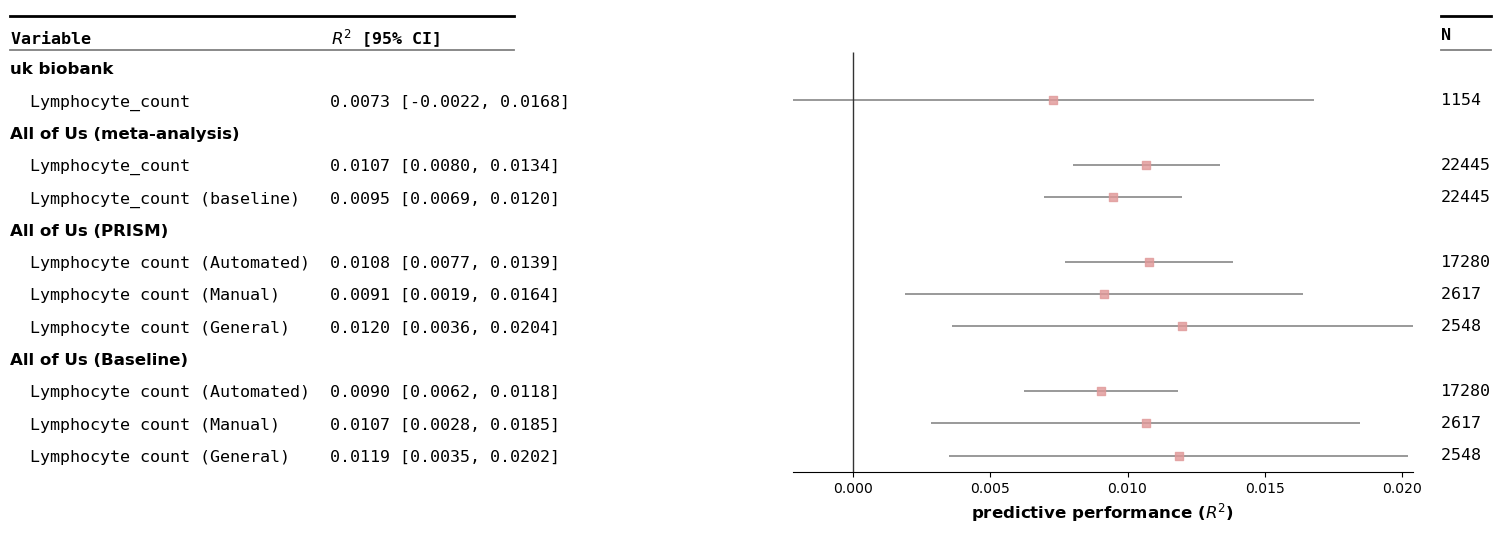

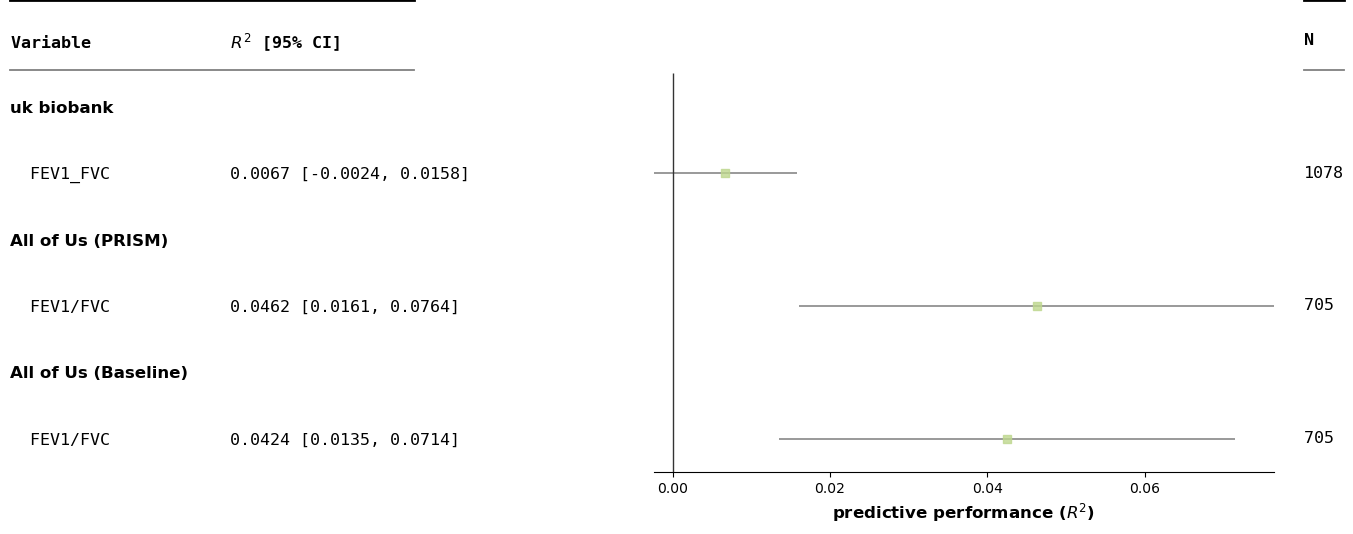

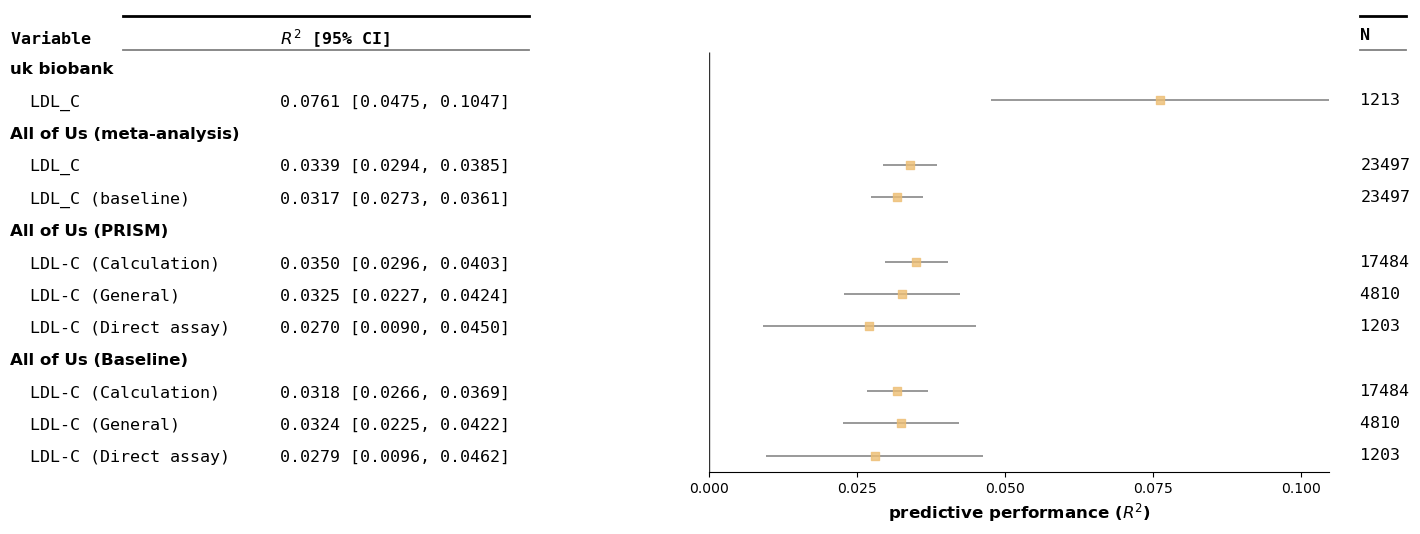

In [43]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

for p in traits:

    plot_df = input_df[input_df['trait'] == p].copy()
    
    # Define the custom cohort order
    cohort_order = ['uk biobank', 'All of Us (meta-analysis)', 'All of Us (PRISM)', 'All of Us (Baseline)']
    
    # Convert 'cohort' to a categorical type with the custom order
    plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=cohort_order, ordered=True)
    
    # Sort by the custom cohort order first, then by 'n' descending within each cohort
    plot_df = plot_df.sort_values(by=['cohort', 'n'], ascending=[True, False])
    
    ax = fp.forestplot(
        plot_df,
        estimate="eval",
        ll="l_eval",
        hl="u_eval",
        varlabel="short_name",
        groupvar="cohort",
        annote=["r2_ci"],
        annoteheaders=[r"$R^{2}$ [95% CI]"],
        rightannote=["n_fmt"],
        right_annoteheaders=["N"],
        title="Forest Plot of Study Results",
        markercolor=trait_colors[p],
        xlabel=r"predictive performance ($R^{2}$)",
        figsize=(8, 6), table=True
    )
    if p == 'LDL_C':
        ax.set_xlim(left=0)
    plt.savefig(f'../baseline_{p}_forest_full.pdf', bbox_inches='tight')